# Bearing Autoencoder — PER ASSET EXPERIMENT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
print('TF version:', tf.__version__)

TF version: 2.16.2


In [3]:
data_root = Path("../NASA_Bearing/IMS")

In [4]:
from unittest import signals


NASA_IMS_CHANNELS = {
    # Experiment 1: two channels per bearing
    1: {
        1: (0, 1),
        2: (2, 3),
        3: (4, 5),
        4: (6, 7),
    },

    # Experiments 2 and 3: one channel per bearing
    2: {
        1: (0,),
        2: (1,),
        3: (2,),
        4: (3,),
    },

    3: {
        1: (0,),
        2: (1,),
        3: (2,),
        4: (3,),
    },
}


def _parse_ims_timestamp(path: Path) -> datetime:
    """
    IMS filenames normally use:
        YYYY.MM.DD.HH.MM.SS

    Example:
        2003.10.22.12.06.24
    """
    try:
        return datetime.strptime(path.name, "%Y.%m.%d.%H.%M.%S")
    except ValueError:
        # Fallback for unexpected filenames.
        return datetime.fromtimestamp(path.stat().st_mtime)


def load_nasa_run(
    experiment_id,
    bearing_id,
    *,
    data_root,
    sensor_index=0,
    warmup_recordings=100,
):
    """
    Load NASA IMS run-to-failure and split it into:
    - early nominal calibration segment
    - monitoring degradation segment
    """

    signals, timestamps, files = load_nasa_ims_bearing(
        experiment_id,
        bearing_id,
        data_root=data_root,
        sensor_index=sensor_index,
    )

    if warmup_recordings >= len(signals):
        raise ValueError(
            "warmup_recordings must be smaller than total recordings"
        )

    early_signal = signals[:warmup_recordings]
    monitoring_signal = signals[warmup_recordings:]

    return {
        "early_signal": early_signal,
        "monitoring_signal": monitoring_signal,

        "early_n_recordings": len(early_signal),
        "monitoring_n_recordings": len(monitoring_signal),

        "early_window_recording_index": np.concatenate(
            [
                np.full(
                    len(
                        make_windows(
                            s,
                            win=WIN,
                            step=STEP,
                        )
                    ),
                    i,
                    dtype=np.int32,
                )
                for i, s in enumerate(early_signal)
            ]
        ),

        "monitoring_window_recording_index": np.repeat(
            np.arange(len(monitoring_signal)),
            [
                len(
                    make_windows(
                        s,
                        win=WIN,
                        step=STEP,
                    )
                )
                for s in monitoring_signal
            ],
        ),

        "timestamps": timestamps,
        "files": files,
    }

def load_nasa_ims_bearing(
    experiment_id: int,
    bearing_id: int,
    *,
    data_root: Path,
    sensor_index: int = 0,
):
    """
    Load one NASA IMS bearing as a chronological run-to-failure sequence.

    Parameters
    ----------
    experiment_id:
        IMS experiment number: 1, 2, or 3.

    bearing_id:
        Physical bearing number: 1, 2, 3, or 4.

    data_root:
        Root directory containing the extracted IMS experiments.

        Expected structure:

            data_root/
                1st_test/
                    2003.10.22.12.06.24
                    ...
                2nd_test/
                    2004.02.12.10.32.39
                    ...
                3rd_test/
                    2004.03.04.09.27.46
                    ...

    sensor_index:
        For experiment 1, each bearing has two sensor channels.
        Use 0 for the first channel or 1 for the second channel.

        Experiments 2 and 3 contain one channel per bearing, so this
        must remain 0.

    Returns
    -------
    signals:
        Array with shape:

            (number_of_recordings, samples_per_recording)

        Each row corresponds to one chronologically ordered IMS file.

    timestamps:
        NumPy array containing one datetime per recording.

    files:
        Ordered list of source file paths.
    """

    experiment_folders = {
        #1: "1st_test",
        2: "2nd_test",
        #3: "3rd_test",
    }

    if experiment_id not in experiment_folders:
        raise ValueError(
            f"experiment_id must be one of {tuple(experiment_folders)}, "
            f"received {experiment_id}"
        )

    if bearing_id not in NASA_IMS_CHANNELS[experiment_id]:
        raise ValueError(
            f"bearing_id must be between 1 and 4, received {bearing_id}"
        )

    channels = NASA_IMS_CHANNELS[experiment_id][bearing_id]

    if sensor_index < 0 or sensor_index >= len(channels):
        raise ValueError(
            f"Experiment {experiment_id}, bearing {bearing_id} has "
            f"{len(channels)} available channel(s); received "
            f"sensor_index={sensor_index}"
        )

    channel = channels[sensor_index]
    folder = Path(data_root) / experiment_folders[experiment_id]

    if not folder.exists():
        raise FileNotFoundError(
            f"IMS experiment folder not found: {folder}"
        )

    files = [
        path
        for path in folder.iterdir()
        if path.is_file() and not path.name.startswith(".")
    ]

    if not files:
        raise FileNotFoundError(
            f"No IMS recording files found in {folder}"
        )

    files = sorted(files, key=_parse_ims_timestamp)

    signals = []
    timestamps = []

    expected_length = None

    for path in files:
        recording = np.loadtxt(path)

        # A file may contain one row or multiple rows.
        if recording.ndim == 1:
            recording = recording[:, np.newaxis]

        if channel >= recording.shape[1]:
            raise ValueError(
                f"File {path.name} contains {recording.shape[1]} channels, "
                f"but channel {channel} was requested."
            )

        signal = recording[:, channel].astype(np.float32)

        if expected_length is None:
            expected_length = len(signal)
        elif len(signal) != expected_length:
            raise ValueError(
                f"Inconsistent recording length in {path.name}: "
                f"expected {expected_length}, found {len(signal)}"
            )

        signals.append(signal)
        timestamps.append(_parse_ims_timestamp(path))

    return (
        np.stack(signals),
        np.asarray(timestamps),
        files,
    )

In [5]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute NASA MSEs first ─────────────────────────────────────────────
def score_windows_mse(signal_1d, *, ae, scaler, win=1200, step=1200):
    ws = make_windows(signal_1d, win=win, step=step)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = shared_ae.predict(X, verbose=0)
    return np.mean((X - X_rec) ** 2, axis=(1, 2))


In [6]:
# ──────────────────────────────────────────────────────────────────────
# NASA IMS configuration
# ──────────────────────────────────────────────────────────────────────

EXPERIMENT_ID = 2

# Physical bearings monitored independently within the experiment.
BEARING_IDS = ("1", "2", "3", "4")

WIN = 1200
STEP = 1200

# Number of chronological IMS recordings used for local initialization.
N_CALIBRATION_RECORDINGS = 100

# Local operational radius.
THRESHOLD_PERCENTILE = 98.0

# Each IMS file contains several 1,200-sample windows.
# Their reconstruction errors are summarized into one score per file.
RECORDING_SCORE_PERCENTILE = 95.0

# Persistent alarm: at least q exceedances among the last p recordings.
PERSISTENCE_Q = 3
PERSISTENCE_P = 5


def load_asset_windows(
    bearing_id: str,
    *,
    experiment_id: int = EXPERIMENT_ID,
    sensor_index: int = 0,
    n_calibration_recordings: int = N_CALIBRATION_RECORDINGS,
    win: int = WIN,
    step: int = STEP,
):
    """
    Load one NASA IMS bearing as a chronological run-to-failure sequence.

    The first `n_calibration_recordings` files form the early-life,
    unlabeled initialization segment. All later recordings are retained
    in chronological order for post-convergence monitoring.

    No random split or temporal shuffling is performed.

    Returns
    -------
    dict
        calibration:
            Windows belonging to the early-life calibration recordings.

        monitoring:
            Windows belonging to the post-calibration recordings.

        all:
            All windows in chronological recording order.

        window_recording_index:
            Recording index associated with each window.

        recording_timestamps:
            Timestamp associated with each IMS recording.

        recording_files:
            Ordered source files.

        n_recordings:
            Total number of IMS recordings.

        n_calibration_recordings:
            Number of early-life recordings used for calibration.
    """
    recordings, timestamps, files = load_nasa_ims_bearing(
        experiment_id=experiment_id,
        bearing_id=int(bearing_id),
        data_root=data_root,
        sensor_index=sensor_index,
    )

    n_recordings = len(recordings)

    if n_recordings <= n_calibration_recordings:
        raise ValueError(
            f"Bearing {bearing_id} contains only {n_recordings} recordings, "
            f"but {n_calibration_recordings} were requested for calibration."
        )

    window_blocks = []
    window_recording_indices = []

    for recording_index, signal in enumerate(recordings):
        signal = np.asarray(signal, dtype=np.float32).reshape(-1)

        recording_windows = make_windows(
            signal,
            win=win,
            step=step,
        ).astype(np.float32)

        if len(recording_windows) == 0:
            continue

        window_blocks.append(recording_windows)

        window_recording_indices.append(
            np.full(
                len(recording_windows),
                recording_index,
                dtype=np.int32,
            )
        )

    if not window_blocks:
        raise ValueError(
            f"No valid {win}-sample windows could be extracted "
            f"for bearing {bearing_id}."
        )

    all_windows = np.concatenate(window_blocks, axis=0)
    window_recording_index = np.concatenate(
        window_recording_indices,
        axis=0,
    )

    calibration_mask = (
        window_recording_index < n_calibration_recordings
    )
    monitoring_mask = ~calibration_mask

    return {
        "bearing_id": str(bearing_id),
        "experiment_id": experiment_id,
        "calibration": all_windows[calibration_mask],
        "monitoring": all_windows[monitoring_mask],
        "all": all_windows,
        "window_recording_index": window_recording_index,
        "recording_timestamps": np.asarray(timestamps),
        "recording_files": files,
        "n_recordings": n_recordings,
        "n_calibration_recordings": n_calibration_recordings,
        "n_calibration_windows": int(np.sum(calibration_mask)),
        "n_monitoring_windows": int(np.sum(monitoring_mask)),
    }


def aggregate_window_scores_by_recording(
    window_scores: np.ndarray,
    window_recording_index: np.ndarray,
    *,
    n_recordings: int,
    score_percentile: float = RECORDING_SCORE_PERCENTILE,
):
    """
    Convert window-level reconstruction errors into one chronological
    anomaly score per IMS recording.

    A high percentile is used instead of the mean so that localized
    anomalous vibration is not diluted by nominal windows in the same
    recording.
    """
    window_scores = np.asarray(
        window_scores,
        dtype=np.float64,
    ).reshape(-1)

    window_recording_index = np.asarray(
        window_recording_index,
        dtype=np.int32,
    ).reshape(-1)

    if len(window_scores) != len(window_recording_index):
        raise ValueError(
            "window_scores and window_recording_index must "
            "have the same length."
        )

    recording_scores = np.full(
        n_recordings,
        np.nan,
        dtype=np.float64,
    )

    for recording_index in range(n_recordings):
        scores = window_scores[
            window_recording_index == recording_index
        ]

        if len(scores) > 0:
            recording_scores[recording_index] = np.percentile(
                scores,
                score_percentile,
            )

    return recording_scores


def find_persistent_departure(
    anomaly_flags: np.ndarray,
    *,
    start_index: int,
    q: int = PERSISTENCE_Q,
    p: int = PERSISTENCE_P,
):
    """
    Return the index at which a persistent alarm can first be declared.

    An alarm is declared when at least `q` of the most recent `p`
    recording-level scores exceed the frozen operational radius.

    The returned index corresponds to the end of the first qualifying
    confirmation interval, i.e. the time at which the decision becomes
    operationally available.
    """
    flags = np.asarray(
        anomaly_flags,
        dtype=bool,
    ).reshape(-1)

    if q < 1 or p < 1 or q > p:
        raise ValueError(
            "Persistence parameters must satisfy 1 <= q <= p."
        )

    first_complete_interval = max(
        start_index + p - 1,
        p - 1,
    )

    for alarm_index in range(
        first_complete_interval,
        len(flags),
    ):
        interval = flags[
            alarm_index - p + 1 : alarm_index + 1
        ]

        if np.sum(interval) >= q:
            return alarm_index

    return None


def evaluate_scores(
    *,
    bearing_id: str,
    detector_name: str,
    recording_scores: np.ndarray,
    recording_timestamps: np.ndarray,
    n_calibration_recordings: int = N_CALIBRATION_RECORDINGS,
    threshold_percentile: float = THRESHOLD_PERCENTILE,
    persistence_q: int = PERSISTENCE_Q,
    persistence_p: int = PERSISTENCE_P,
):
    """
    Evaluate one NASA IMS bearing chronologically.

    Larger scores must always mean more anomalous.

    The operational radius is estimated exclusively from the early-life
    initialization recordings and is then frozen. Persistent departure is
    searched only after the initialization interval.
    """
    recording_scores = np.asarray(
        recording_scores,
        dtype=np.float64,
    ).reshape(-1)

    recording_timestamps = np.asarray(
        recording_timestamps,
    ).reshape(-1)

    if len(recording_scores) != len(recording_timestamps):
        raise ValueError(
            "recording_scores and recording_timestamps must "
            "have the same length."
        )

    if len(recording_scores) <= n_calibration_recordings:
        raise ValueError(
            "The sequence must contain recordings after calibration."
        )

    valid_mask = np.isfinite(recording_scores)

    calibration_mask = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    calibration_mask[:n_calibration_recordings] = True
    calibration_mask &= valid_mask

    monitoring_mask = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    monitoring_mask[n_calibration_recordings:] = True
    monitoring_mask &= valid_mask

    calibration_scores = recording_scores[calibration_mask]
    monitoring_scores = recording_scores[monitoring_mask]

    if len(calibration_scores) == 0:
        raise ValueError(
            "No finite scores are available in the calibration segment."
        )

    tau = float(
        np.percentile(
            calibration_scores,
            threshold_percentile,
        )
    )

    anomaly_flags = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    anomaly_flags[valid_mask] = (
        recording_scores[valid_mask] > tau
    )

    alarm_index = find_persistent_departure(
        anomaly_flags,
        start_index=n_calibration_recordings,
        q=persistence_q,
        p=persistence_p,
    )

    if alarm_index is None:
        alarm_timestamp = None
        lead_time_hours = None
        lead_time_recordings = None
    else:
        alarm_timestamp = recording_timestamps[alarm_index]

        lead_time = (
            recording_timestamps[-1]
            - recording_timestamps[alarm_index]
        )

        # Handles datetime.timedelta and numpy.timedelta64.
        if isinstance(lead_time, np.timedelta64):
            lead_time_hours = float(
                lead_time / np.timedelta64(1, "h")
            )
        else:
            lead_time_hours = (
                lead_time.total_seconds() / 3600.0
            )

        lead_time_recordings = (
            len(recording_scores) - 1 - alarm_index
        )

    return {
        "bearing_id": str(bearing_id),
        "detector": detector_name,
        "threshold_percentile": threshold_percentile,
        "threshold": tau,
        "recording_score_percentile": (
            RECORDING_SCORE_PERCENTILE
        ),
        "n_recordings": len(recording_scores),
        "n_calibration_recordings": (
            n_calibration_recordings
        ),
        "n_monitoring_recordings": len(
            monitoring_scores
        ),
        "calibration_exceedance_rate": (
            100.0
            * np.mean(calibration_scores > tau)
        ),
        "monitoring_exceedance_rate": (
            100.0
            * np.mean(monitoring_scores > tau)
        ),
        "persistence_q": persistence_q,
        "persistence_p": persistence_p,
        "persistent_departure_detected": (
            alarm_index is not None
        ),
        "alarm_index": alarm_index,
        "alarm_timestamp": alarm_timestamp,
        "lead_time_recordings": lead_time_recordings,
        "lead_time_hours": lead_time_hours,
        "end_timestamp": recording_timestamps[-1],
    }

In [7]:
LATENT_DIM = 16
SIG_LEN = 1200

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-27 22:16:04.226132: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-27 22:16:04.226318: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-27 22:16:04.226328: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-27 22:16:04.226485: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-27 22:16:04.226498: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
STABILITY_SEEDS = [7, 21, 42, 84, 126]

ae_results = []

# Store residual trajectories for stability comparison
field_asset_residuals = {}

for seed in STABILITY_SEEDS:

    print("\n==========================")
    print(f"Seed {seed}")
    print("==========================")

    for bearing_id in BEARING_IDS:

        print(
            f"\nTraining asset-specific early-life AE "
            f"for NASA IMS bearing {bearing_id}..."
        )

        # Clear the previous asset model before creating a new one.
        keras.backend.clear_session()

        np.random.seed(seed)
        tf.random.set_seed(seed)

        try:
            keras.utils.set_random_seed(seed)
        except Exception:
            pass

        # -------------------------------------------------------
        # Load chronological NASA IMS data
        # -------------------------------------------------------

        asset = load_asset_windows(
            bearing_id=bearing_id,
            experiment_id=EXPERIMENT_ID,
            n_calibration_recordings=N_CALIBRATION_RECORDINGS,
            win=WIN,
            step=STEP,
        )

        X_calibration_raw = asset["calibration"].reshape(
            len(asset["calibration"]),
            -1,
        )

        X_all_raw = asset["all"].reshape(
            len(asset["all"]),
            -1,
        )

        print(
            f"  recordings: {asset['n_recordings']}"
            f"\n  calibration recordings: "
            f"{asset['n_calibration_recordings']}"
            f"\n  calibration windows: "
            f"{asset['n_calibration_windows']}"
            f"\n  monitoring windows: "
            f"{asset['n_monitoring_windows']}"
        )

        # -------------------------------------------------------
        # Asset-specific preprocessing
        #
        # IMPORTANT:
        # The scaler is fitted only on the early-life calibration
        # segment. No future recording is used for preprocessing.
        # -------------------------------------------------------

        scaler = StandardScaler()

        X_calibration_sc = scaler.fit_transform(
            X_calibration_raw
        ).astype(np.float32)

        X_all_sc = scaler.transform(
            X_all_raw
        ).astype(np.float32)

        X_calibration = X_calibration_sc[..., np.newaxis]
        X_all = X_all_sc[..., np.newaxis]

        # -------------------------------------------------------
        # Asset-specific model
        # -------------------------------------------------------

        ae, encoder = build_autoencoder(
            sig_len=X_calibration.shape[1],
            latent_dim=LATENT_DIM,
        )

        ae.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss="mse",
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-5,
            ),
        ]

        history = ae.fit(
            X_calibration,
            X_calibration,
            validation_split=0.20,
            epochs=100,
            batch_size=32,

            # Training samples may be shuffled because all belong
            # to the early-life nominal calibration interval.
            shuffle=True,

            callbacks=callbacks,
            verbose=0,
        )

        # -------------------------------------------------------
        # Window-level reconstruction scores over the complete
        # chronological run-to-failure sequence
        # -------------------------------------------------------

        all_rec = ae.predict(
            X_all,
            batch_size=256,
            verbose=0,
        )

        window_scores = np.mean(
            np.square(X_all - all_rec),
            axis=(1, 2),
        )

        # -------------------------------------------------------
        # Store asset-specific AE residual trajectory
        # for identical stability analysis
        # -------------------------------------------------------

        field_asset_residuals[
            (str(bearing_id), seed)
        ] = {

            # window-level anomaly scores
            "window_scores":
                window_scores,

            # mapping window -> IMS recording
            "window_recording_index":
                asset["window_recording_index"],

            # chronological metadata
            "n_recordings":
                asset["n_recordings"],

            "n_calibration_recordings":
                asset["n_calibration_recordings"],

            "n_calibration_windows":
                asset["n_calibration_windows"],

            "n_monitoring_windows":
                asset["n_monitoring_windows"],

            # useful for comparison
            "recording_scores":
                aggregate_window_scores_by_recording(
                    window_scores=window_scores,
                    window_recording_index=(
                        asset["window_recording_index"]
                    ),
                    n_recordings=asset["n_recordings"],
                    score_percentile=RECORDING_SCORE_PERCENTILE,
                ),
        }
        
        # -------------------------------------------------------
        # Aggregate all windows from each IMS file into one
        # recording-level anomaly score
        # -------------------------------------------------------

        recording_scores = aggregate_window_scores_by_recording(
            window_scores=window_scores,
            window_recording_index=(
                asset["window_recording_index"]
            ),
            n_recordings=asset["n_recordings"],
            score_percentile=RECORDING_SCORE_PERCENTILE,
        )

        # -------------------------------------------------------
        # Chronological run-to-failure evaluation
        # -------------------------------------------------------

        row = evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific early-life AE",
            recording_scores=recording_scores,
            recording_timestamps=(
                asset["recording_timestamps"]
            ),
            n_calibration_recordings=(
                asset["n_calibration_recordings"]
            ),
            threshold_percentile=THRESHOLD_PERCENTILE,
            persistence_q=PERSISTENCE_Q,
            persistence_p=PERSISTENCE_P,
        )

        row["seed"] = seed
        row["experiment_id"] = EXPERIMENT_ID
        row["n_calibration_windows"] = (
            asset["n_calibration_windows"]
        )
        row["n_monitoring_windows"] = (
            asset["n_monitoring_windows"]
        )
        row["epochs_trained"] = len(history.history["loss"])
        row["final_train_loss"] = float(
            history.history["loss"][-1]
        )
        row["best_val_loss"] = float(
            np.min(history.history["val_loss"])
        )

        ae_results.append(row)


# -------------------------------------------------------
# Final dataframe
# -------------------------------------------------------

ae_results = pd.DataFrame(ae_results)

display(ae_results)



Seed 7

Training asset-specific early-life AE for NASA IMS bearing 1...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028


2026-07-27 22:16:11.473564: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Training asset-specific early-life AE for NASA IMS bearing 2...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028

Training asset-specific early-life AE for NASA IMS bearing 3...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028

Training asset-specific early-life AE for NASA IMS bearing 4...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028

Seed 21

Training asset-specific early-life AE for NASA IMS bearing 1...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028

Training asset-specific early-life AE for NASA IMS bearing 2...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028

Training asset-specific early-life AE for NASA IMS bearing 3...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  mon

,bearing_id,detector,threshold_percentile,threshold,recording_score_percentile,n_recordings,n_calibration_recordings,n_monitoring_recordings,calibration_exceedance_rate,monitoring_exceedance_rate,...,lead_time_recordings,lead_time_hours,end_timestamp,seed,experiment_id,n_calibration_windows,n_monitoring_windows,epochs_trained,final_train_loss,best_val_loss
0,1,Asset-specific early-life AE,98.0,0.976449,95.0,984,100,884,2.0,53.393665,...,522,87.000000,2004-02-19 06:22:39,7,2,1700,15028,21,0.724378,0.788365
1,2,Asset-specific early-life AE,98.0,0.917440,95.0,984,100,884,2.0,15.837104,...,155,25.833333,2004-02-19 06:22:39,7,2,1700,15028,17,0.685554,0.745493
2,3,Asset-specific early-life AE,98.0,1.232889,95.0,984,100,884,2.0,10.633484,...,90,15.000000,2004-02-19 06:22:39,7,2,1700,15028,12,1.008239,0.967006
3,4,Asset-specific early-life AE,98.0,1.214795,95.0,984,100,884,2.0,38.800905,...,366,61.000000,2004-02-19 06:22:39,7,2,1700,15028,11,1.000283,0.998854
4,1,Asset-specific early-life AE,98.0,0.979157,95.0,984,100,884,2.0,53.506787,...,449,74.833333,2004-02-19 06:22:39,21,2,1700,15028,19,0.727001,0.784422
5,2,Asset-specific early-life AE,98.0,0.909820,95.0,984,100,884,2.0,16.289593,...,143,23.833333,2004-02-19 06:22:39,21,2,1700,15028,18,0.679934,0.740429
6,3,Asset-specific early-life AE,98.0,1.232906,95.0,984,100,884,2.0,10.633484,...,90,15.000000,2004-02-19 06:22:39,21,2,1700,15028,11,1.008246,0.966992
7,4,Asset-specific early-life AE,98.0,1.049866,95.0,984,100,884,2.0,41.628959,...,445,74.166667,2004-02-19 06:22:39,21,2,1700,15028,16,0.780627,0.847427
8,1,Asset-specific early-life AE,98.0,0.969513,95.0,984,100,884,2.0,54.072398,...,528,88.000000,2004-02-19 06:22:39,42,2,1700,15028,20,0.729318,0.783698
9,2,Asset-specific early-life AE,98.0,0.907895,95.0,984,100,884,2.0,17.194570,...,269,44.833333,2004-02-19 06:22:39,42,2,1700,15028,20,0.679706,0.740212


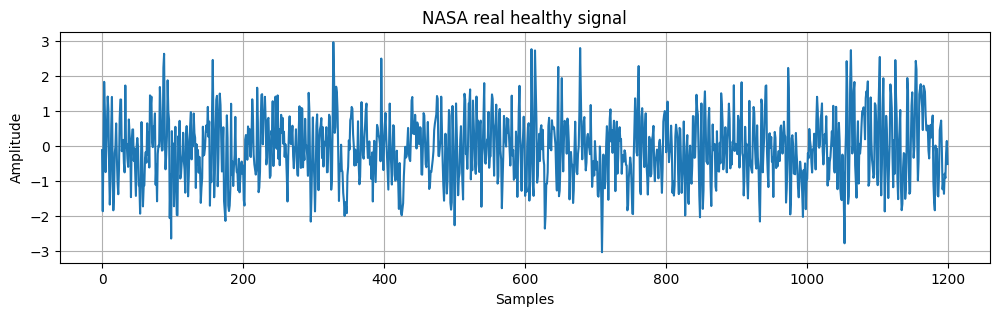

In [9]:
x = X_calibration[0].reshape(-1)

plt.figure(figsize=(12,3))
plt.plot(x)
plt.title("NASA real healthy signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

In [10]:
ae_stability_summary = (
    ae_results
    .groupby(
        [
            "experiment_id",
            "bearing_id",
            "detector",
        ],
        as_index=False,
    )
    .agg(
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),

        calibration_exceedance_mean=(
            "calibration_exceedance_rate",
            "mean",
        ),
        calibration_exceedance_std=(
            "calibration_exceedance_rate",
            "std",
        ),

        monitoring_exceedance_mean=(
            "monitoring_exceedance_rate",
            "mean",
        ),
        monitoring_exceedance_std=(
            "monitoring_exceedance_rate",
            "std",
        ),

        alarm_detection_rate=(
            "persistent_departure_detected",
            "mean",
        ),

        alarm_index_mean=("alarm_index", "mean"),
        alarm_index_std=("alarm_index", "std"),

        lead_time_hours_mean=("lead_time_hours", "mean"),
        lead_time_hours_std=("lead_time_hours", "std"),

        lead_time_recordings_mean=(
            "lead_time_recordings",
            "mean",
        ),
        lead_time_recordings_std=(
            "lead_time_recordings",
            "std",
        ),

        epochs_mean=("epochs_trained", "mean"),
        epochs_std=("epochs_trained", "std"),
    )
)

ae_stability_summary["alarm_detection_rate"] *= 100.0

display(ae_stability_summary)

,experiment_id,bearing_id,detector,threshold_mean,threshold_std,calibration_exceedance_mean,calibration_exceedance_std,monitoring_exceedance_mean,monitoring_exceedance_std,alarm_detection_rate,alarm_index_mean,alarm_index_std,lead_time_hours_mean,lead_time_hours_std,lead_time_recordings_mean,lead_time_recordings_std,epochs_mean,epochs_std
0,2,1,Asset-specific early-life AE,1.027580,0.112687,2.0,0.0,53.076923,1.077337,100.0,503.6,41.680931,79.900000,6.946822,479.4,41.680931,20.2,1.303840
1,2,2,Asset-specific early-life AE,0.968092,0.124821,2.0,0.0,17.692308,2.561662,100.0,784.8,64.816665,33.033333,10.802777,198.2,64.816665,16.8,3.420526
2,2,3,Asset-specific early-life AE,1.232949,0.000051,2.0,0.0,10.633484,0.000000,100.0,893.0,0.000000,15.000000,0.000000,90.0,0.000000,15.8,9.628084
3,2,4,Asset-specific early-life AE,1.181810,0.073759,2.0,0.0,39.366516,1.264744,100.0,601.2,35.329874,63.633333,5.888312,381.8,35.329874,19.6,11.238327


In [11]:
display(ae_results)

print(field_asset_residuals.keys())

,bearing_id,detector,threshold_percentile,threshold,recording_score_percentile,n_recordings,n_calibration_recordings,n_monitoring_recordings,calibration_exceedance_rate,monitoring_exceedance_rate,...,lead_time_recordings,lead_time_hours,end_timestamp,seed,experiment_id,n_calibration_windows,n_monitoring_windows,epochs_trained,final_train_loss,best_val_loss
0,1,Asset-specific early-life AE,98.0,0.976449,95.0,984,100,884,2.0,53.393665,...,522,87.000000,2004-02-19 06:22:39,7,2,1700,15028,21,0.724378,0.788365
1,2,Asset-specific early-life AE,98.0,0.917440,95.0,984,100,884,2.0,15.837104,...,155,25.833333,2004-02-19 06:22:39,7,2,1700,15028,17,0.685554,0.745493
2,3,Asset-specific early-life AE,98.0,1.232889,95.0,984,100,884,2.0,10.633484,...,90,15.000000,2004-02-19 06:22:39,7,2,1700,15028,12,1.008239,0.967006
3,4,Asset-specific early-life AE,98.0,1.214795,95.0,984,100,884,2.0,38.800905,...,366,61.000000,2004-02-19 06:22:39,7,2,1700,15028,11,1.000283,0.998854
4,1,Asset-specific early-life AE,98.0,0.979157,95.0,984,100,884,2.0,53.506787,...,449,74.833333,2004-02-19 06:22:39,21,2,1700,15028,19,0.727001,0.784422
5,2,Asset-specific early-life AE,98.0,0.909820,95.0,984,100,884,2.0,16.289593,...,143,23.833333,2004-02-19 06:22:39,21,2,1700,15028,18,0.679934,0.740429
6,3,Asset-specific early-life AE,98.0,1.232906,95.0,984,100,884,2.0,10.633484,...,90,15.000000,2004-02-19 06:22:39,21,2,1700,15028,11,1.008246,0.966992
7,4,Asset-specific early-life AE,98.0,1.049866,95.0,984,100,884,2.0,41.628959,...,445,74.166667,2004-02-19 06:22:39,21,2,1700,15028,16,0.780627,0.847427
8,1,Asset-specific early-life AE,98.0,0.969513,95.0,984,100,884,2.0,54.072398,...,528,88.000000,2004-02-19 06:22:39,42,2,1700,15028,20,0.729318,0.783698
9,2,Asset-specific early-life AE,98.0,0.907895,95.0,984,100,884,2.0,17.194570,...,269,44.833333,2004-02-19 06:22:39,42,2,1700,15028,20,0.679706,0.740212


dict_keys([('1', 7), ('2', 7), ('3', 7), ('4', 7), ('1', 21), ('2', 21), ('3', 21), ('4', 21), ('1', 42), ('2', 42), ('3', 42), ('4', 42), ('1', 84), ('2', 84), ('3', 84), ('4', 84), ('1', 126), ('2', 126), ('3', 126), ('4', 126)])


### METHOD TEST

In [12]:
# =====================================================================
# TRAIN THE FIXED OEM / SHARED NASA SIMULATOR-TRAINED MODEL
# =====================================================================

from bearing_simulator import (
    BearingSignalSimulator,
    NASA_PARAMS,
)

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

OEM_SEED = 42

keras.backend.clear_session()
keras.utils.set_random_seed(OEM_SEED)
np.random.seed(OEM_SEED)
tf.random.set_seed(OEM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ---------------------------------------------------------------------
# Synthetic NASA simulator configuration
# ---------------------------------------------------------------------

shared_simulator = BearingSignalSimulator(
    NASA_PARAMS
)

#shared_sig_len = len(shared_simulator.t)
shared_sig_len = SIG_LEN # BECAUSE NASA IS 20KHZ


SYNTHETIC_REGIMES = [
    "healthy",
    "outer_race",
    "inner_race",
    "ball_fault",
]


SYNTHETIC_LABELS = {
    "healthy": 0,
    "outer_race": 1,
    "inner_race": 2,
    "ball_fault": 3,
}


N_SYNTHETIC_TRAIN = 4000
N_SYNTHETIC_VAL = 1000
N_SYNTHETIC_TEST = 750


SHARED_LATENT_DIM = 16
SHARED_THRESHOLD_PERCENTILE = 98.0


print(
    f"Shared NASA synthetic signal length: {shared_sig_len} samples"
)


# ---------------------------------------------------------------------
# Generate OEM healthy training and validation data
# ---------------------------------------------------------------------

def generate_oem_healthy(n):

    samples = []

    while len(samples) < n:

        signal = shared_simulator.sample(
            regime="healthy",
            mc=True,
            coverage="wide",
            asset_signature=np.random.uniform(
                0.8,
                1.2,
                5,
            ),
        )

        windows = make_windows(
            signal,
            win=SIG_LEN,
            step=STEP,
        )

        samples.extend(windows)

    return np.asarray(
        samples[:n],
        dtype=np.float32,
    )


def generate_oem_regime(n, regime):

    samples = []

    while len(samples) < n:

        signal = shared_simulator.sample(
            regime=regime,
            mc=True,
            coverage="wide",
            asset_signature=np.random.uniform(
                0.8,
                1.2,
                5,
            ),
        )

        windows = make_windows(
            signal,
            win=SIG_LEN,
            step=STEP,
        )

        samples.extend(windows)

    return np.asarray(
        samples[:n],
        dtype=np.float32,
    )

X_shared_train_raw = generate_oem_healthy(
    N_SYNTHETIC_TRAIN
)


X_shared_val_raw = generate_oem_healthy(
    N_SYNTHETIC_VAL
)


# ---------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------

shared_scaler = StandardScaler()


X_shared_train_sc = shared_scaler.fit_transform(
    X_shared_train_raw
).astype(np.float32)


X_shared_val_sc = shared_scaler.transform(
    X_shared_val_raw
).astype(np.float32)


X_shared_train = X_shared_train_sc[..., np.newaxis]
X_shared_val = X_shared_val_sc[..., np.newaxis]


# ---------------------------------------------------------------------
# Independent synthetic NASA test set
# ---------------------------------------------------------------------

shared_test_by_regime = {}
shared_y_test_parts = []


for regime in SYNTHETIC_REGIMES:

    regime_raw = generate_oem_regime(
    N_SYNTHETIC_TEST,
    regime,
)


    regime_sc = shared_scaler.transform(
        regime_raw
    ).astype(np.float32)


    shared_test_by_regime[regime] = (
        regime_sc[..., np.newaxis]
    )


    shared_y_test_parts.append(
        np.full(
            N_SYNTHETIC_TEST,
            SYNTHETIC_LABELS[regime],
            dtype=np.int64,
        )
    )


X_shared_test = np.concatenate(
    [
        shared_test_by_regime[r]
        for r in SYNTHETIC_REGIMES
    ],
    axis=0,
)


y_shared_test = np.concatenate(
    shared_y_test_parts
)


print(
    f"Train: {X_shared_train.shape} | "
    f"Validation: {X_shared_val.shape} | "
    f"Test: {X_shared_test.shape}"
)


# ---------------------------------------------------------------------
# Build fixed OEM NASA AE
# ---------------------------------------------------------------------

shared_ae, shared_encoder = build_autoencoder(
    sig_len=shared_sig_len,
    latent_dim=SHARED_LATENT_DIM,
)


shared_ae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
)


shared_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]


shared_history = shared_ae.fit(
    X_shared_train,
    X_shared_train,
    validation_data=(
        X_shared_val,
        X_shared_val,
    ),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=shared_callbacks,
    verbose=1,
)

# ---------------------------------------------------------------------
# OEM threshold calibration
# ---------------------------------------------------------------------

X_shared_val_rec = shared_ae.predict(
    X_shared_val,
    verbose=0,
)


shared_val_mse = np.mean(
    np.square(
        X_shared_val - X_shared_val_rec
    ),
    axis=(1,2),
)


shared_tau_mc = float(
    np.percentile(
        shared_val_mse,
        SHARED_THRESHOLD_PERCENTILE,
    )
)


print(
    f"\nNASA synthetic OEM threshold "
    f"τ_MC(p{SHARED_THRESHOLD_PERCENTILE:.0f})"
    f" = {shared_tau_mc:.6f}"
)


# ---------------------------------------------------------------------
# Synthetic sanity evaluation
# ---------------------------------------------------------------------

X_shared_test_rec = shared_ae.predict(
    X_shared_test,
    verbose=0,
)


shared_test_mse = np.mean(
    np.square(
        X_shared_test - X_shared_test_rec
    ),
    axis=(1,2),
)


def synthetic_rate(regime):

    mask = (
        y_shared_test
        ==
        SYNTHETIC_LABELS[regime]
    )

    return (
        100
        *
        np.mean(
            shared_test_mse[mask]
            >
            shared_tau_mc
        )
    )


synthetic_ae_results = pd.DataFrame(
    [
        {
            "dataset": "NASA synthetic",
            "detector": "Shared NASA simulator-trained AE",
            "threshold": shared_tau_mc,
            "healthy_far": synthetic_rate("healthy"),
            "ball_dr": synthetic_rate("ball_fault"),
            "inner_race_dr": synthetic_rate("inner_race"),
            "outer_race_dr": synthetic_rate("outer_race"),
            "n_train": N_SYNTHETIC_TRAIN,
            "n_validation": N_SYNTHETIC_VAL,
        }
    ]
)


display(synthetic_ae_results)


# ---------------------------------------------------------------------
# Artifacts
# ---------------------------------------------------------------------

assert shared_ae is not None
assert shared_scaler is not None
assert np.isfinite(shared_tau_mc)


print("\nFixed NASA OEM artifacts created:")
print("  shared_ae")
print("  shared_encoder")
print("  shared_scaler")
print("  shared_tau_mc")
print("  shared_history")

print(X_shared_train_raw.shape)
print(X_shared_val_raw.shape)
print(regime_raw.shape)

Shared NASA synthetic signal length: 1200 samples
Train: (4000, 1200, 1) | Validation: (1000, 1200, 1) | Test: (3000, 1200, 1)
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.2315 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0363 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0243 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0189 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0163 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0139 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0136 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0161 - val_loss: 0.0144 -

,dataset,detector,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_train,n_validation
0,NASA synthetic,Shared NASA simulator-trained AE,0.012016,1.333333,40.666667,98.4,88.666667,4000,1000



Fixed NASA OEM artifacts created:
  shared_ae
  shared_encoder
  shared_scaler
  shared_tau_mc
  shared_history
(4000, 1200)
(1000, 1200)
(750, 1200)


### DOMAIN ADAPTATION ###

In [13]:
# =====================================================================
# NASA IMS — convergence-based local calibration
# =====================================================================

TARGET_PERCENTILE = 98.0
MIN_WARMUP_SAMPLES = 20

MIN_CALIBRATION_SIZE = 40
MAX_CALIBRATION_SIZE = 200

CONVERGENCE_LOOKBACK = 10
CONVERGENCE_TOLERANCE = 0.01
CONVERGENCE_CONSECUTIVE = 10

In [14]:
# =====================================================================
# Online operational-radius estimator
# =====================================================================

class AdaptiveOperationalRadius:
    """
    Online empirical-quantile estimator.

    The globally shared quantity is the target nominal coverage
    (e.g. 98%), not a z-score or an absolute threshold.

    The local operational radius is estimated as the empirical
    percentile of the accepted nominal residuals.
    """

    def __init__(
        self,
        percentile=98.0,
        window_size=100,
        min_samples=20,
    ):
        if not 0.0 < percentile < 100.0:
            raise ValueError("percentile must be between 0 and 100.")

        if window_size < 2:
            raise ValueError("window_size must be at least 2.")

        if min_samples < 2:
            raise ValueError("min_samples must be at least 2.")

        if min_samples > window_size:
            raise ValueError(
                "min_samples cannot be larger than window_size."
            )

        self.percentile = float(percentile)
        self.window_size = int(window_size)
        self.min_samples = int(min_samples)

        self.buf = deque(maxlen=self.window_size)

    def update(self, mse_value):
        """
        Add one nominal residual and update the operational radius.

        Returns
        -------
        tau : float
            Current operational radius. NaN until min_samples is reached.
        """
        self.buf.append(float(mse_value))

        if len(self.buf) < self.min_samples:
            return np.nan

        arr = np.asarray(self.buf, dtype=np.float64)

        return float(
            np.percentile(
                arr,
                self.percentile,
            )
        )

    def warmup_trace(self, mse_sequence):
        """
        Process an entire warm-up sequence and return tau(t).
        """
        history_tau = []

        for mse_value in mse_sequence:
            history_tau.append(
                self.update(mse_value)
            )

        return np.asarray(history_tau, dtype=np.float64)


# =====================================================================
# Convergence utilities
# =====================================================================

def operational_radius_convergence_trace(
    tau_history,
    *,
    lookback=10,
    eps=1e-12,
):
    """
    Relative variation of tau over a fixed look-back interval.

    C(t) = |tau(t) - tau(t-L)| / max(|tau(t-L)|, eps)
    """
    tau_history = np.asarray(tau_history, dtype=np.float64)

    convergence = np.full(
        tau_history.shape,
        np.nan,
        dtype=np.float64,
    )

    for t in range(lookback, len(tau_history)):
        current = tau_history[t]
        previous = tau_history[t - lookback]

        if np.isfinite(current) and np.isfinite(previous):
            convergence[t] = (
                abs(current - previous)
                / max(abs(previous), eps)
            )

    return convergence


def find_convergence_index(
    tau_history,
    *,
    lookback=10,
    tolerance=0.01,
    consecutive=10,
    min_index=0,
):
    """
    Return the first zero-based index at which the operational radius
    remains stable for `consecutive` updates.

    Convergence is not evaluated before `min_index`.
    """
    convergence = operational_radius_convergence_trace(
        tau_history,
        lookback=lookback,
    )

    stable_count = 0

    for t, value in enumerate(convergence):

        if t < min_index:
            stable_count = 0
            continue

        if np.isfinite(value) and value < tolerance:
            stable_count += 1

            if stable_count >= consecutive:
                return t
        else:
            stable_count = 0

    return None

# =====================================================================
# Shared simulator-trained AE applied unchanged to NASA IMS
# =====================================================================

def run_nasa_experiment(
    bearing_id,
    *,
    target_percentile=TARGET_PERCENTILE,
    min_calibration_size=MIN_CALIBRATION_SIZE,
    max_calibration_size=MAX_CALIBRATION_SIZE,
    min_warmup_samples=MIN_WARMUP_SAMPLES,
    convergence_lookback=CONVERGENCE_LOOKBACK,
    convergence_tolerance=CONVERGENCE_TOLERANCE,
    convergence_consecutive=CONVERGENCE_CONSECUTIVE,
):
    """
    Evaluate the fixed shared simulator-trained AE on one NASA IMS bearing.

    Deployment protocol
    -------------------
    1. The shared AE and scaler remain frozen.
    2. Chronological early-life observations are processed sequentially.
    3. Convergence is evaluated only after N_min observations.
    4. Calibration stops at convergence or at N_max.
    5. If convergence is detected, tau is frozen and monitoring begins
       immediately after the convergence point.
    6. If convergence is not detected by N_max, the bearing is not
       released into active monitoring.

    Important
    ---------
    The scoring function used here must preserve chronological order.
    For recording-level results, it must return one aggregate score per
    NASA recording.
    """

    min_calibration_size = int(min_calibration_size)
    requested_max_calibration_size = int(max_calibration_size)

    if min_calibration_size < min_warmup_samples:
        raise ValueError(
            "min_calibration_size cannot be smaller than "
            "min_warmup_samples."
        )

    if min_calibration_size > requested_max_calibration_size:
        raise ValueError(
            "min_calibration_size cannot exceed "
            "max_calibration_size."
        )

    # -----------------------------------------------------------------
    # Load the complete chronological trajectory
    #
    # The loader creates a prefix of N_max recordings and the remaining
    # run. We later concatenate their scores and start monitoring at the
    # actual convergence point, not at N_max.
    # -----------------------------------------------------------------

    run = load_nasa_run(
        experiment_id=2,
        bearing_id=bearing_id,
        data_root=data_root,
        sensor_index=0,
        warmup_recordings=requested_max_calibration_size,
    )

    candidate_signal = run["early_signal"]
    remaining_signal = run["monitoring_signal"]

    print(f"\nNASA IMS bearing: {bearing_id}")
    print("Candidate calibration prefix:", candidate_signal.shape)
    print("Remaining trajectory:", remaining_signal.shape)

    # -----------------------------------------------------------------
    # Absolute simulator threshold
    # -----------------------------------------------------------------

    if "shared_tau_mc" in globals():
        tau_mc = float(shared_tau_mc)
        mse_mc_healthy = None

    else:
        X_shared_train_rec = shared_ae.predict(
            X_shared_train,
            verbose=0,
        )

        mse_mc_healthy = np.mean(
            np.square(
                X_shared_train
                - X_shared_train_rec
            ),
            axis=(1, 2),
        )

        tau_mc = float(
            np.percentile(
                mse_mc_healthy,
                target_percentile,
            )
        )

    # -----------------------------------------------------------------
    # Score the complete chronological NASA trajectory at recording level
    # -----------------------------------------------------------------

    mse_candidate = shared_nasa_recording_scores(
        candidate_signal
    )

    mse_remaining = shared_nasa_recording_scores(
        remaining_signal
    )

    mse_candidate = np.asarray(
        mse_candidate,
        dtype=np.float64,
    )

    mse_remaining = np.asarray(
        mse_remaining,
        dtype=np.float64,
    )

    mse_all = np.concatenate(
        [
            mse_candidate,
            mse_remaining,
        ]
    )

    print(
        "Recording-level scores → "
        f"candidate:{len(mse_candidate)} "
        f"remaining:{len(mse_remaining)} "
        f"complete:{len(mse_all)}"
    )

    # -----------------------------------------------------------------
    # Effective calibration limits
    # -----------------------------------------------------------------

    max_calibration_size = min(
        requested_max_calibration_size,
        len(mse_candidate),
    )

    if min_calibration_size > max_calibration_size:
        raise ValueError(
            f"Bearing {bearing_id}: only "
            f"{max_calibration_size} calibration recordings are "
            f"available, fewer than N_min={min_calibration_size}."
        )

    calibration_candidates = mse_candidate[
        :max_calibration_size
    ]

    # -----------------------------------------------------------------
    # Sequential empirical-p98 calibration
    # -----------------------------------------------------------------

    adaptive = AdaptiveOperationalRadius(
        percentile=target_percentile,
        window_size=max_calibration_size,
        min_samples=min_warmup_samples,
    )

    tau_history = adaptive.warmup_trace(
        calibration_candidates
    )

    valid_tau = tau_history[
        np.isfinite(tau_history)
    ]

    if len(valid_tau) == 0:
        raise RuntimeError(
            "The NASA operational radius did not initialize."
        )

    convergence_index = find_convergence_index(
        tau_history,
        lookback=convergence_lookback,
        tolerance=convergence_tolerance,
        consecutive=convergence_consecutive,
        min_index=min_calibration_size - 1,
    )

    if convergence_index is None:
        convergence_window = np.nan
        calibration_size = max_calibration_size
        calibration_status = "not_converged"
        tau_online = np.nan

    else:
        convergence_window = convergence_index + 1
        calibration_size = convergence_window
        calibration_status = "converged"

        tau_online = float(
            tau_history[convergence_index]
        )

    # -----------------------------------------------------------------
    # Retrospective early-life oracle
    #
    # This uses the complete candidate early-life interval and is only
    # an analytical reference. It is unavailable to the online method
    # at its stopping time.
    # -----------------------------------------------------------------

    tau_field_oracle = float(
        np.percentile(
            calibration_candidates,
            target_percentile,
        )
    )

    if np.isfinite(tau_online):
        tau_absolute_error = abs(
            tau_online - tau_field_oracle
        )

        tau_relative_error_pct = (
            100.0
            * tau_absolute_error
            / max(
                abs(tau_field_oracle),
                1e-12,
            )
        )

    else:
        tau_absolute_error = np.nan
        tau_relative_error_pct = np.nan

    # -----------------------------------------------------------------
    # Monitoring begins immediately after convergence
    # -----------------------------------------------------------------

    if calibration_status == "converged":
        mse_calibration = mse_all[
            :calibration_size
        ]

        mse_monitoring = mse_all[
            calibration_size:
        ]

        monitoring_start_index = calibration_size

    else:
        mse_calibration = mse_all[
            :max_calibration_size
        ]

        mse_monitoring = np.asarray(
            [],
            dtype=np.float64,
        )

        monitoring_start_index = np.nan

    # -----------------------------------------------------------------
    # Metric helpers
    # -----------------------------------------------------------------

    def alarm_rate(scores, threshold):
        if (
            len(scores) == 0
            or not np.isfinite(threshold)
        ):
            return np.nan

        return 100.0 * float(
            np.mean(
                scores > threshold
            )
        )

    def first_alarm_index(scores, threshold):
        if (
            len(scores) == 0
            or not np.isfinite(threshold)
        ):
            return np.nan

        alarm_mask = scores > threshold

        if not np.any(alarm_mask):
            return np.nan

        return int(
            np.flatnonzero(alarm_mask)[0]
        )

    # -----------------------------------------------------------------
    # Compare calibration strategies
    # -----------------------------------------------------------------

    thresholds = {
        "absolute_mc": tau_mc,
        "field_oracle": tau_field_oracle,
    }

    if calibration_status == "converged":
        thresholds["online_radius"] = tau_online

    rows = []

    for threshold_name, threshold_value in thresholds.items():

        if threshold_name == "absolute_mc":
            threshold_status = "not_applicable"
            threshold_calibration_size = 0
            threshold_convergence_index = np.nan
            threshold_convergence_window = np.nan

        elif threshold_name == "field_oracle":
            threshold_status = "oracle"
            threshold_calibration_size = max_calibration_size
            threshold_convergence_index = np.nan
            threshold_convergence_window = np.nan

        else:
            threshold_status = calibration_status
            threshold_calibration_size = calibration_size
            threshold_convergence_index = convergence_index
            threshold_convergence_window = convergence_window

        threshold_first_alarm = first_alarm_index(
            mse_monitoring,
            threshold_value,
        )

        absolute_alarm_index = (
            monitoring_start_index
            + threshold_first_alarm
            if (
                np.isfinite(monitoring_start_index)
                and np.isfinite(threshold_first_alarm)
            )
            else np.nan
        )

        rows.append(
            {
                "bearing_id": str(bearing_id),
                "detector": (
                    "Shared NASA simulator-trained AE"
                ),
                "calibration": threshold_name,
                "threshold_percentile": target_percentile,
                "threshold": threshold_value,

                "calibration_status": threshold_status,
                "min_calibration_size": (
                    min_calibration_size
                    if threshold_name == "online_radius"
                    else np.nan
                ),
                "max_calibration_size": (
                    max_calibration_size
                    if threshold_name == "online_radius"
                    else np.nan
                ),
                "calibration_size": (
                    threshold_calibration_size
                ),
                "convergence_index": (
                    threshold_convergence_index
                ),
                "convergence_window": (
                    threshold_convergence_window
                ),

                "calibration_exceedance_rate": alarm_rate(
                    mse_calibration,
                    threshold_value,
                ),
                "monitoring_exceedance_rate": alarm_rate(
                    mse_monitoring,
                    threshold_value,
                ),

                # Index relative to the monitoring segment.
                "alarm_index": threshold_first_alarm,

                # Index relative to the complete trajectory.
                "absolute_alarm_index": absolute_alarm_index,

                "monitoring_start_index": (
                    monitoring_start_index
                ),
                "monitoring_observations": len(
                    mse_monitoring
                ),

                "tau_field_oracle": (
                    tau_field_oracle
                ),
                "tau_absolute_error": (
                    tau_absolute_error
                    if threshold_name == "online_radius"
                    else np.nan
                ),
                "tau_relative_error_pct": (
                    tau_relative_error_pct
                    if threshold_name == "online_radius"
                    else np.nan
                ),
            }
        )

    results_table = pd.DataFrame(rows)

    # -----------------------------------------------------------------
    # Output
    # -----------------------------------------------------------------

    print("\nThresholds")
    print(f"τ_MC absolute        = {tau_mc:.6f}")
    print(f"τ_early-life oracle  = {tau_field_oracle:.6f}")

    if calibration_status == "converged":
        print(f"τ_online             = {tau_online:.6f}")
        print(
            "Relative oracle error = "
            f"{tau_relative_error_pct:.2f}%"
        )
        print(
            "Convergence detected at "
            f"observation {convergence_window}."
        )
        print(
            "Monitoring begins at complete-trajectory "
            f"index {monitoring_start_index}."
        )

    else:
        print("τ_online             = not deployed")
        print(
            "Operational-radius convergence was not detected "
            f"within N_max={max_calibration_size}."
        )

    print(f"Calibration status   = {calibration_status}")
    print(f"Calibration samples  = {calibration_size}")

    display(results_table)

    return {
        "bearing_id": str(bearing_id),

        "mse_mc_healthy": mse_mc_healthy,
        "mse_all": mse_all,
        "mse_candidate": mse_candidate,
        "mse_remaining": mse_remaining,

        "mse_calibration": mse_calibration,
        "mse_monitoring": mse_monitoring,
        "tau_history": tau_history,

        "tau_mc": tau_mc,
        "tau_field_oracle": tau_field_oracle,
        "tau_online": tau_online,
        "tau_absolute_error": tau_absolute_error,
        "tau_relative_error_pct": tau_relative_error_pct,

        "min_calibration_size": min_calibration_size,
        "max_calibration_size": max_calibration_size,
        "calibration_size": calibration_size,
        "calibration_status": calibration_status,

        "convergence_index": convergence_index,
        "convergence_window": convergence_window,
        "monitoring_start_index": monitoring_start_index,

        "results_table": results_table,
    }

#### STABILITY

In [18]:
# ---------------------------------------------------------------------
# Fixed-model NASA scoring at RECORDING level
# ---------------------------------------------------------------------

def shared_nasa_recording_scores(signal):
    """
    Apply the frozen shared simulator-trained AE to NASA IMS recordings.

    Parameters
    ----------
    signal : array_like
        Expected shape:
            (n_recordings, samples_per_recording)

    Returns
    -------
    recording_scores : np.ndarray
        One reconstruction score per NASA recording.

    Notes
    -----
    Each recording is divided into non-overlapping windows. The recording
    score is the mean reconstruction MSE across its internal windows.

    If the main recording-level NASA experiment uses another aggregation
    rule, such as the maximum or a high percentile, replace only the
    aggregation line below so both experiments remain identical.
    """

    recording_scores = []

    for recording_id, recording in enumerate(signal):

        windows = make_windows(
            recording,
            win=shared_sig_len,
            step=STEP,
        )

        if len(windows) == 0:
            raise ValueError(
                f"Recording {recording_id} does not contain a complete "
                f"{shared_sig_len}-sample window."
            )

        windows = np.asarray(
            windows,
            dtype=np.float32,
        )

        windows_2d = windows.reshape(
            windows.shape[0],
            -1,
        )

        windows_scaled = shared_scaler.transform(
            windows_2d
        ).astype(np.float32)

        X = windows_scaled[..., np.newaxis]

        X_rec = shared_ae.predict(
            X,
            verbose=0,
        )

        window_scores = np.mean(
            np.square(X - X_rec),
            axis=(1, 2),
        )

        # Must match the aggregation used in the main NASA experiment.
        recording_score = float(
            np.mean(window_scores)
        )

        recording_scores.append(
            recording_score
        )

    return np.asarray(
        recording_scores,
        dtype=np.float64,
    )


In [19]:
RECORDING_INTERVAL_HOURS = 0.1666667   # 10 minutes per IMS recording

In [20]:
NASA_BEARING_IDS = [1, 2, 3, 4]

nasa_results = {}

for bearing_id in NASA_BEARING_IDS:

    result = run_nasa_experiment(
        bearing_id,
        target_percentile=TARGET_PERCENTILE,
        min_calibration_size=MIN_CALIBRATION_SIZE,
        max_calibration_size=MAX_CALIBRATION_SIZE,
        min_warmup_samples=MIN_WARMUP_SAMPLES,
        convergence_lookback=CONVERGENCE_LOOKBACK,
        convergence_tolerance=CONVERGENCE_TOLERANCE,
        convergence_consecutive=CONVERGENCE_CONSECUTIVE,
    )

    nasa_results[str(bearing_id)] = result


NASA IMS bearing: 1
Candidate calibration prefix: (200, 20480)
Remaining trajectory: (784, 20480)
Recording-level scores → candidate:200 remaining:784 complete:984

Thresholds
τ_MC absolute        = 0.012016
τ_early-life oracle  = 0.010669
τ_online             = 0.010680
Relative oracle error = 0.10%
Convergence detected at observation 49.
Monitoring begins at complete-trajectory index 49.
Calibration status   = converged
Calibration samples  = 49


,bearing_id,detector,calibration,threshold_percentile,threshold,calibration_status,min_calibration_size,max_calibration_size,calibration_size,convergence_index,convergence_window,calibration_exceedance_rate,monitoring_exceedance_rate,alarm_index,absolute_alarm_index,monitoring_start_index,monitoring_observations,tau_field_oracle,tau_absolute_error,tau_relative_error_pct
0,1,Shared NASA simulator-trained AE,absolute_mc,98.0,0.012016,not_applicable,NaN,NaN,0,NaN,NaN,0.000000,46.631016,489,538,49,935,0.010669,NaN,NaN
1,1,Shared NASA simulator-trained AE,field_oracle,98.0,0.010669,oracle,NaN,NaN,200,NaN,NaN,4.081633,48.663102,67,116,49,935,0.010669,NaN,NaN
2,1,Shared NASA simulator-trained AE,online_radius,98.0,0.010680,converged,40.0,200.0,49,48.0,49.0,2.040816,48.556150,108,157,49,935,0.010669,0.000011,0.104516



NASA IMS bearing: 2
Candidate calibration prefix: (200, 20480)
Remaining trajectory: (784, 20480)
Recording-level scores → candidate:200 remaining:784 complete:984

Thresholds
τ_MC absolute        = 0.012016
τ_early-life oracle  = 0.014899
τ_online             = 0.014950
Relative oracle error = 0.35%
Convergence detected at observation 57.
Monitoring begins at complete-trajectory index 57.
Calibration status   = converged
Calibration samples  = 57


,bearing_id,detector,calibration,threshold_percentile,threshold,calibration_status,min_calibration_size,max_calibration_size,calibration_size,convergence_index,convergence_window,calibration_exceedance_rate,monitoring_exceedance_rate,alarm_index,absolute_alarm_index,monitoring_start_index,monitoring_observations,tau_field_oracle,tau_absolute_error,tau_relative_error_pct
0,2,Shared NASA simulator-trained AE,absolute_mc,98.0,0.012016,not_applicable,NaN,NaN,0,NaN,NaN,100.000000,99.784250,0,57,57,927,0.014899,NaN,NaN
1,2,Shared NASA simulator-trained AE,field_oracle,98.0,0.014899,oracle,NaN,NaN,200,NaN,NaN,3.508772,26.537217,2,59,57,927,0.014899,NaN,NaN
2,2,Shared NASA simulator-trained AE,online_radius,98.0,0.014950,converged,40.0,200.0,57,56.0,57.0,3.508772,25.134844,2,59,57,927,0.014899,0.000051,0.345112



NASA IMS bearing: 3
Candidate calibration prefix: (200, 20480)
Remaining trajectory: (784, 20480)
Recording-level scores → candidate:200 remaining:784 complete:984

Thresholds
τ_MC absolute        = 0.012016
τ_early-life oracle  = 0.018401
τ_online             = 0.018930
Relative oracle error = 2.87%
Convergence detected at observation 49.
Monitoring begins at complete-trajectory index 49.
Calibration status   = converged
Calibration samples  = 49


,bearing_id,detector,calibration,threshold_percentile,threshold,calibration_status,min_calibration_size,max_calibration_size,calibration_size,convergence_index,convergence_window,calibration_exceedance_rate,monitoring_exceedance_rate,alarm_index,absolute_alarm_index,monitoring_start_index,monitoring_observations,tau_field_oracle,tau_absolute_error,tau_relative_error_pct
0,3,Shared NASA simulator-trained AE,absolute_mc,98.0,0.012016,not_applicable,NaN,NaN,0,NaN,NaN,100.000000,99.786096,0,49,49,935,0.018401,NaN,NaN
1,3,Shared NASA simulator-trained AE,field_oracle,98.0,0.018401,oracle,NaN,NaN,200,NaN,NaN,8.163265,10.802139,828,877,49,935,0.018401,NaN,NaN
2,3,Shared NASA simulator-trained AE,online_radius,98.0,0.018930,converged,40.0,200.0,49,48.0,49.0,2.040816,10.053476,836,885,49,935,0.018401,0.000529,2.874172



NASA IMS bearing: 4
Candidate calibration prefix: (200, 20480)
Remaining trajectory: (784, 20480)
Recording-level scores → candidate:200 remaining:784 complete:984

Thresholds
τ_MC absolute        = 0.012016
τ_early-life oracle  = 0.006684
τ_online             = 0.006672
Relative oracle error = 0.18%
Convergence detected at observation 49.
Monitoring begins at complete-trajectory index 49.
Calibration status   = converged
Calibration samples  = 49


,bearing_id,detector,calibration,threshold_percentile,threshold,calibration_status,min_calibration_size,max_calibration_size,calibration_size,convergence_index,convergence_window,calibration_exceedance_rate,monitoring_exceedance_rate,alarm_index,absolute_alarm_index,monitoring_start_index,monitoring_observations,tau_field_oracle,tau_absolute_error,tau_relative_error_pct
0,4,Shared NASA simulator-trained AE,absolute_mc,98.0,0.012016,not_applicable,NaN,NaN,0,NaN,NaN,0.000000,4.705882,886,935,49,935,0.006684,NaN,NaN
1,4,Shared NASA simulator-trained AE,field_oracle,98.0,0.006684,oracle,NaN,NaN,200,NaN,NaN,0.000000,37.219251,4,53,49,935,0.006684,NaN,NaN
2,4,Shared NASA simulator-trained AE,online_radius,98.0,0.006672,converged,40.0,200.0,49,48.0,49.0,2.040816,37.860963,4,53,49,935,0.006684,0.000012,0.176684


In [ ]:
# =====================================================================
# NASA IMS — ROBUSTNESS TO LOCAL COMMISSIONING VARIABILITY
#
# Fixed shared representation; different early-life recording samples
# and arrival orders.
#
# Important:
# - Calibration is performed at RECORDING level.
# - Only the first N_max chronological recordings define the nominal
#   early-life reference pool.
# - Later run-to-failure recordings are never used in this experiment.
# =====================================================================

NASA_BEARING_IDS = [1, 2, 3, 4]

STABILITY_SEEDS = [
    7,
    21,
    42,
    84,
    126,
]

TARGET_PERCENTILE = 98.0
MIN_WARMUP_SAMPLES = 20

MIN_CALIBRATION_SIZE = 40
MAX_CALIBRATION_SIZE = 200

CONVERGENCE_LOOKBACK = 10
CONVERGENCE_TOLERANCE = 0.01
CONVERGENCE_CONSECUTIVE = 10


# ---------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------

required_objects = [
    "shared_ae",
    "shared_scaler",
    "shared_sig_len",
    "AdaptiveOperationalRadius",
    "find_convergence_index",
    "make_windows",
    "load_nasa_run",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing)
        + ". Run the shared-model and calibration-definition cells first."
    )


STEP = int(shared_sig_len)

# ---------------------------------------------------------------------
# Compute fixed early-life recording scores once
#
# The first N_max chronological recordings form the reference nominal pool.
# The later degradation trajectory is intentionally excluded.
# ---------------------------------------------------------------------

early_life_recording_scores = {}

for bearing_id in NASA_BEARING_IDS:

    print(
        f"Computing early-life recording scores "
        f"for NASA bearing {bearing_id}..."
    )

    run = load_nasa_run(
        experiment_id=2,
        bearing_id=bearing_id,
        data_root=data_root,
        sensor_index=0,
        warmup_recordings=MAX_CALIBRATION_SIZE,
    )

    early_signal = np.asarray(
        run["early_signal"]
    )

    recording_scores = shared_nasa_recording_scores(
        early_signal
    )

    if len(recording_scores) < MIN_CALIBRATION_SIZE:
        raise ValueError(
            f"Bearing {bearing_id}: only {len(recording_scores)} "
            f"early-life recording scores are available."
        )

    early_life_recording_scores[
        str(bearing_id)
    ] = recording_scores

    print(
        f"Bearing {bearing_id}: "
        f"{len(recording_scores)} early-life recordings"
    )


# ---------------------------------------------------------------------
# Stability experiment
#
# For each bearing and seed:
# 1. Randomly permute the early-life recording scores.
# 2. Estimate the empirical p98 sequentially.
# 3. Begin checking convergence after N_min.
# 4. Freeze tau at the first valid convergence point.
# 5. Evaluate FAR on early-life recordings not used before convergence.
# 6. Do not deploy a radius when convergence is not achieved.
# ---------------------------------------------------------------------

nasa_stability_rows = []
nasa_stability_traces = {}

for seed in STABILITY_SEEDS:

    print("\n" + "=" * 76)
    print(f"NASA commissioning seed: {seed}")
    print("=" * 76)

    for bearing_id in NASA_BEARING_IDS:

        bearing_key = str(bearing_id)

        healthy_scores = np.asarray(
            early_life_recording_scores[bearing_key],
            dtype=np.float64,
        )

        n_healthy = len(
            healthy_scores
        )

        effective_max_calibration_size = min(
            int(MAX_CALIBRATION_SIZE),
            n_healthy,
        )

        if (
            MIN_CALIBRATION_SIZE
            > effective_max_calibration_size
        ):
            raise ValueError(
                f"Bearing {bearing_id}: N_min="
                f"{MIN_CALIBRATION_SIZE} exceeds the available "
                f"maximum calibration size "
                f"{effective_max_calibration_size}."
            )

        # -------------------------------------------------------------
        # Reproducible sample selection and simulated arrival order
        # -------------------------------------------------------------

        rng = np.random.default_rng(
            seed + bearing_id
        )

        permutation = rng.permutation(
            n_healthy
        )

        candidate_indices = permutation[
            :effective_max_calibration_size
        ]

        candidate_scores = healthy_scores[
            candidate_indices
        ]

        # -------------------------------------------------------------
        # Sequential empirical-p98 calibration
        # -------------------------------------------------------------

        adaptive = AdaptiveOperationalRadius(
            percentile=TARGET_PERCENTILE,
            window_size=effective_max_calibration_size,
            min_samples=MIN_WARMUP_SAMPLES,
        )

        tau_history = adaptive.warmup_trace(
            candidate_scores
        )

        valid_tau = tau_history[
            np.isfinite(tau_history)
        ]

        if len(valid_tau) == 0:
            raise RuntimeError(
                f"Bearing {bearing_id}, seed {seed}: "
                "the operational radius did not initialize."
            )

        convergence_index = find_convergence_index(
            tau_history,
            lookback=CONVERGENCE_LOOKBACK,
            tolerance=CONVERGENCE_TOLERANCE,
            consecutive=CONVERGENCE_CONSECUTIVE,
            min_index=MIN_CALIBRATION_SIZE - 1,
        )

        converged = (
            convergence_index is not None
        )

        if converged:

            convergence_window = (
                convergence_index + 1
            )

            calibration_size = int(
                convergence_window
            )

            calibration_status = "converged"

            tau_online = float(
                tau_history[convergence_index]
            )

            used_calibration_indices = (
                candidate_indices[:calibration_size]
            )

            # Independent early-life evaluation set:
            # every recording not used before convergence.
            healthy_test_indices = np.setdiff1d(
                np.arange(n_healthy),
                used_calibration_indices,
                assume_unique=False,
            )

            healthy_test_scores = healthy_scores[
                healthy_test_indices
            ]

        else:

            convergence_window = np.nan
            calibration_size = (
                effective_max_calibration_size
            )

            calibration_status = (
                "not_converged"
            )

            tau_online = np.nan

            used_calibration_indices = (
                candidate_indices.copy()
            )

            healthy_test_indices = np.setdiff1d(
                np.arange(n_healthy),
                used_calibration_indices,
                assume_unique=False,
            )

            healthy_test_scores = healthy_scores[
                healthy_test_indices
            ]

        # -------------------------------------------------------------
        # Complete early-life oracle
        #
        # Retrospective reference only. It uses the entire early-life
        # recording pool but no later degradation recordings.
        # -------------------------------------------------------------

        tau_field_oracle = float(
            np.percentile(
                healthy_scores,
                TARGET_PERCENTILE,
            )
        )

        if converged:

            tau_absolute_error = abs(
                tau_online - tau_field_oracle
            )

            tau_relative_error_pct = (
                100.0
                * tau_absolute_error
                / max(
                    abs(tau_field_oracle),
                    1e-12,
                )
            )

            healthy_far = (
                100.0
                * float(
                    np.mean(
                        healthy_test_scores
                        > tau_online
                    )
                )
            )

        else:

            tau_absolute_error = np.nan
            tau_relative_error_pct = np.nan
            healthy_far = np.nan

        # -------------------------------------------------------------
        # Store result
        # -------------------------------------------------------------

        row = {
            "bearing_id": bearing_key,
            "seed": seed,

            "detector": (
                "Fixed shared NASA simulator-trained AE"
            ),

            "calibration": (
                "convergence_based_recording_p98"
            ),

            "threshold_percentile": (
                TARGET_PERCENTILE
            ),

            "calibration_status": (
                calibration_status
            ),

            "calibration_success": (
                converged
            ),

            "min_calibration_size": (
                MIN_CALIBRATION_SIZE
            ),

            "max_calibration_size": (
                effective_max_calibration_size
            ),

            "calibration_size": (
                calibration_size
            ),

            "convergence_index": (
                convergence_index
                if converged
                else np.nan
            ),

            "convergence_window": (
                convergence_window
            ),

            "tau_online": (
                tau_online
            ),

            "tau_field_oracle": (
                tau_field_oracle
            ),

            "tau_absolute_error": (
                tau_absolute_error
            ),

            "tau_relative_error_pct": (
                tau_relative_error_pct
            ),

            "healthy_far": (
                healthy_far
            ),

            "n_calibration": (
                calibration_size
            ),

            "n_healthy_test": len(
                healthy_test_scores
            ),

            "n_early_life_recordings": (
                n_healthy
            ),
        }

        nasa_stability_rows.append(
            row
        )

        nasa_stability_traces[
            (bearing_key, seed)
        ] = {
            "permutation": (
                permutation.copy()
            ),

            "candidate_indices": (
                candidate_indices.copy()
            ),

            "candidate_scores": (
                candidate_scores.copy()
            ),

            "used_calibration_indices": (
                used_calibration_indices.copy()
            ),

            "healthy_test_indices": (
                healthy_test_indices.copy()
            ),

            "healthy_test_scores": (
                healthy_test_scores.copy()
            ),

            "tau_history": (
                tau_history.copy()
            ),

            "tau_online": (
                tau_online
            ),

            "tau_field_oracle": (
                tau_field_oracle
            ),

            "convergence_index": (
                convergence_index
            ),

            "convergence_window": (
                convergence_window
            ),

            "calibration_status": (
                calibration_status
            ),
        }

        if converged:

            print(
                f"Bearing {bearing_id} | "
                f"status=converged | "
                f"N={calibration_size} | "
                f"tau={tau_online:.6f} | "
                f"oracle={tau_field_oracle:.6f} | "
                f"error={tau_relative_error_pct:.2f}% | "
                f"FAR={healthy_far:.2f}%"
            )

        else:

            print(
                f"Bearing {bearing_id} | "
                f"status=NOT CONVERGED within "
                f"N_max={effective_max_calibration_size}"
            )


# ---------------------------------------------------------------------
# Long-form results
# ---------------------------------------------------------------------

nasa_initialization_stability_results = pd.DataFrame(
    nasa_stability_rows
)

display(
    nasa_initialization_stability_results
)


# ---------------------------------------------------------------------
# Summary by bearing
#
# Pandas excludes NaN deployment metrics from numerical means.
# Calibration success is reported separately.
# ---------------------------------------------------------------------

nasa_initialization_stability_by_bearing = (
    nasa_initialization_stability_results
    .groupby(
        "bearing_id",
        as_index=False,
    )
    .agg(
        successful_runs=(
            "calibration_success",
            "sum",
        ),

        total_runs=(
            "calibration_success",
            "size",
        ),

        tau_online_mean=(
            "tau_online",
            "mean",
        ),

        tau_online_std=(
            "tau_online",
            "std",
        ),

        tau_field_oracle=(
            "tau_field_oracle",
            "first",
        ),

        tau_relative_error_mean=(
            "tau_relative_error_pct",
            "mean",
        ),

        tau_relative_error_std=(
            "tau_relative_error_pct",
            "std",
        ),

        healthy_far_mean=(
            "healthy_far",
            "mean",
        ),

        healthy_far_std=(
            "healthy_far",
            "std",
        ),

        calibration_mean=(
            "convergence_window",
            "mean",
        ),

        calibration_std=(
            "convergence_window",
            "std",
        ),
    )
)

nasa_initialization_stability_by_bearing[
    "calibration_success_rate_pct"
] = (
    100.0
    * nasa_initialization_stability_by_bearing[
        "successful_runs"
    ]
    / nasa_initialization_stability_by_bearing[
        "total_runs"
    ]
)

display(
    nasa_initialization_stability_by_bearing
)


# ---------------------------------------------------------------------
# Global calibration success
# ---------------------------------------------------------------------

total_runs = len(
    nasa_initialization_stability_results
)

successful_runs = int(
    nasa_initialization_stability_results[
        "calibration_success"
    ].sum()
)

global_success_rate_pct = (
    100.0
    * successful_runs
    / total_runs
)

print(
    "\nNASA global calibration success: "
    f"{successful_runs}/{total_runs} "
    f"({global_success_rate_pct:.1f}%)"
)


# ---------------------------------------------------------------------
# Seed-level fleet averages
# ---------------------------------------------------------------------

nasa_seed_summary = (
    nasa_initialization_stability_results
    .groupby("seed")
    .agg(
        calibration_success_rate=(
            "calibration_success",
            "mean",
        ),

        healthy_far=(
            "healthy_far",
            "mean",
        ),

        tau_relative_error_pct=(
            "tau_relative_error_pct",
            "mean",
        ),

        convergence_window=(
            "convergence_window",
            "mean",
        ),
    )
)

nasa_seed_summary[
    "calibration_success_rate"
] *= 100.0

display(
    nasa_seed_summary
)


# ---------------------------------------------------------------------
# Global variability across seed-level bearing averages
# ---------------------------------------------------------------------

nasa_global_stability_summary = pd.DataFrame(
    {
        "mean": (
            nasa_seed_summary.mean()
        ),

        "std": (
            nasa_seed_summary.std(
                ddof=1
            )
        ),

        "min": (
            nasa_seed_summary.min()
        ),

        "max": (
            nasa_seed_summary.max()
        ),
    }
)

display(
    nasa_global_stability_summary
)

Computing early-life recording scores for NASA bearing 1...
Bearing 1: 200 early-life recordings
Computing early-life recording scores for NASA bearing 2...
Bearing 2: 200 early-life recordings
Computing early-life recording scores for NASA bearing 3...
Bearing 3: 200 early-life recordings
Computing early-life recording scores for NASA bearing 4...
Bearing 4: 200 early-life recordings

NASA commissioning seed: 7
Bearing 1 | status=converged | N=49 | tau=0.010565 | oracle=0.010669 | error=0.97% | FAR=5.96%
Bearing 2 | status=converged | N=49 | tau=0.014861 | oracle=0.014899 | error=0.25% | FAR=3.97%
Bearing 3 | status=converged | N=65 | tau=0.018483 | oracle=0.018401 | error=0.45% | FAR=1.48%
Bearing 4 | status=converged | N=49 | tau=0.006617 | oracle=0.006684 | error=0.99% | FAR=6.62%

NASA commissioning seed: 21
Bearing 1 | status=converged | N=49 | tau=0.010669 | oracle=0.010669 | error=0.00% | FAR=1.99%
Bearing 2 | status=converged | N=49 | tau=0.014898 | oracle=0.014899 | error=0.0

,bearing_id,seed,detector,calibration,threshold_percentile,calibration_status,calibration_success,min_calibration_size,max_calibration_size,calibration_size,convergence_index,convergence_window,tau_online,tau_field_oracle,tau_absolute_error,tau_relative_error_pct,healthy_far,n_calibration,n_healthy_test,n_early_life_recordings
0,1,7,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.010565,0.010669,1.031060e-04,0.966447,5.960265,49,151,200
1,2,7,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.014861,0.014899,3.778934e-05,0.253640,3.973510,49,151,200
2,3,7,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,65,64,65,0.018483,0.018401,8.227825e-05,0.447140,1.481481,65,135,200
3,4,7,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.006617,0.006684,6.623538e-05,0.991005,6.622517,49,151,200
4,1,21,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.010669,0.010669,8.624047e-09,0.000081,1.986755,49,151,200
5,2,21,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.014898,0.014899,5.385280e-07,0.003615,2.649007,49,151,200
6,3,21,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.018420,0.018401,1.885965e-05,0.102493,1.986755,49,151,200
7,4,21,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.006684,0.006684,1.609325e-07,0.002408,1.986755,49,151,200
8,1,42,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.010666,0.010669,2.764110e-06,0.025909,2.649007,49,151,200
9,2,42,Fixed shared NASA simulator-trained AE,convergence_based_recording_p98,98.0,converged,True,40,200,49,48,49,0.014738,0.014899,1.607257e-04,1.078781,9.271523,49,151,200


,bearing_id,successful_runs,total_runs,tau_online_mean,tau_online_std,tau_field_oracle,tau_relative_error_mean,tau_relative_error_std,healthy_far_mean,healthy_far_std,calibration_mean,calibration_std,calibration_success_rate_pct
0,1,5,5,0.010590,0.000074,0.010669,0.733214,0.698067,5.842826,3.785116,49.2,0.447214,100.0
1,2,5,5,0.014873,0.000084,0.014899,0.363094,0.438633,3.708609,3.331067,49.0,0.000000,100.0
2,3,5,5,0.018151,0.000383,0.018401,1.577002,1.877974,4.932058,4.223444,52.2,7.155418,100.0
3,4,5,5,0.006640,0.000033,0.006684,0.658128,0.489245,5.446572,2.394127,49.6,1.341641,100.0



NASA global calibration success: 20/20 (100.0%)


,calibration_success_rate,healthy_far,tau_relative_error_pct,convergence_window
seed,,,,
7,100.0,4.509443,0.664558,53.0
21,100.0,2.152318,0.027149,49.0
42,100.0,7.781457,1.534126,49.0
84,100.0,5.005787,0.500759,50.0
126,100.0,5.463576,1.437707,49.0


,mean,std,min,max
calibration_success_rate,100.000000,0.000000,100.000000,100.000000
healthy_far,4.982516,2.018654,2.152318,7.781457
tau_relative_error_pct,0.832860,0.641366,0.027149,1.534126
convergence_window,50.000000,1.732051,49.000000,53.000000


In [ ]:
# =====================================================================
# EDGE FOOTPRINT MEASUREMENT
# Requires: shared_ae, shared_sig_len
# =====================================================================

import os
import time
import tempfile


# ---------------------------------------------------------------------
# 1. Parameter and raw-weight size
# ---------------------------------------------------------------------

parameter_count = shared_ae.count_params()

float32_weight_bytes = parameter_count * np.dtype(np.float32).itemsize
float32_weight_mb = float32_weight_bytes / 1_000_000
float32_weight_mib = float32_weight_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 2. Exact serialized model size
# Save without optimizer state, because deployment uses inference only.
# ---------------------------------------------------------------------

with tempfile.TemporaryDirectory() as tmpdir:
    keras_path = os.path.join(tmpdir, "shared_oem_model.keras")

    # Clone/compile state is not required for inference.
    shared_ae.save(
        keras_path,
        include_optimizer=False,
    )

    serialized_bytes = os.path.getsize(keras_path)
    serialized_mb = serialized_bytes / 1_000_000
    serialized_mib = serialized_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 3. Local calibration-state size
# Compact implementation: 100 float32 residuals plus a few scalar values.
# ---------------------------------------------------------------------

LOCAL_BUFFER_LENGTH = 100

residual_buffer_bytes = (
    LOCAL_BUFFER_LENGTH * np.dtype(np.float32).itemsize
)

# Example compact scalar state:
# current tau, previous tau, percentile, tolerance,
# convergence counter, state flag, and sample counter.
estimated_scalar_state_bytes = (
    4 * np.dtype(np.float32).itemsize
    + 3 * np.dtype(np.int32).itemsize
)

local_state_bytes = (
    residual_buffer_bytes + estimated_scalar_state_bytes
)


# ---------------------------------------------------------------------
# 4. Batch-1 CPU inference latency
# Use a real-shaped input. shared_ae is kept fixed.
# ---------------------------------------------------------------------

benchmark_input = np.zeros(
    (1, shared_sig_len, 1),
    dtype=np.float32,
)

benchmark_tensor = tf.convert_to_tensor(benchmark_input)

# Warm-up: TensorFlow tracing, memory allocation, and caches
N_WARMUP = 50
for _ in range(N_WARMUP):
    _ = shared_ae(
        benchmark_tensor,
        training=False,
    )

# Timed runs
N_RUNS = 500
latencies_ms = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    output = shared_ae(
        benchmark_tensor,
        training=False,
    )

    # Force completion before stopping the clock
    _ = output.numpy()

    elapsed_ms = (
        time.perf_counter() - start
    ) * 1000.0

    latencies_ms.append(elapsed_ms)

latencies_ms = np.asarray(latencies_ms)

latency_median_ms = float(np.median(latencies_ms))
latency_mean_ms = float(np.mean(latencies_ms))
latency_std_ms = float(np.std(latencies_ms, ddof=1))
latency_p95_ms = float(np.percentile(latencies_ms, 95))


# ---------------------------------------------------------------------
# 5. Results
# ---------------------------------------------------------------------

edge_footprint = pd.DataFrame(
    [
        {
            "metric": "Model parameters",
            "value": f"{parameter_count:,}",
        },
        {
            "metric": "Raw float32 weight size",
            "value": (
                f"{float32_weight_mb:.2f} MB "
                f"({float32_weight_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "Serialized .keras size",
            "value": (
                f"{serialized_mb:.2f} MB "
                f"({serialized_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "CPU latency, median",
            "value": f"{latency_median_ms:.3f} ms/window",
        },
        {
            "metric": "CPU latency, mean ± std",
            "value": (
                f"{latency_mean_ms:.3f} ± "
                f"{latency_std_ms:.3f} ms/window"
            ),
        },
        {
            "metric": "CPU latency, p95",
            "value": f"{latency_p95_ms:.3f} ms/window",
        },
        {
            "metric": "Local residual-buffer length",
            "value": str(LOCAL_BUFFER_LENGTH),
        },
        {
            "metric": "Residual-buffer memory",
            "value": f"{residual_buffer_bytes} bytes",
        },
        {
            "metric": "Estimated compact local state",
            "value": (
                f"{local_state_bytes} bytes "
                f"(< 1 kB)"
            ),
        },
        {
            "metric": "Per-asset model training",
            "value": "None",
        },
        {
            "metric": "Fault labels required",
            "value": "None",
        },
    ]
)

display(edge_footprint)